### Marche aléatoire classique
Nous étudions la marche aléatoire classique de 100 particules pour 100 éléments de diffusion.
Dans un premier temps on s'intéresse à la trajectoire de ces particules.

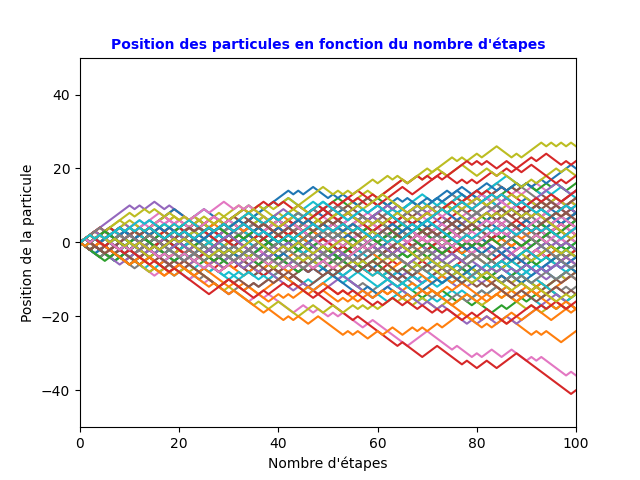

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
N=100 #nombre d'éléments de diffusion
t=np.zeros(N+1)
T=np.zeros(N+1)
n=np.arange(N+1)
plt.xlim(0,100)
plt.ylim(-50,50)
Seau=[]
for j in range (100) :
    for i in range (len(t)):
        t[i]=random.choice([-1,1]) #modélise le résulat du lancer de pièce au niveau de l'élément de diffusion i (Coin)
    for l in range (len(T)-1): 
        T[l+1]=T[l]+t[l] #modélise le déplacement du marcheur suite au lancer de pièce (Shift)
    Seau.append(T[N]) #position final du marcheur
    plt.plot(n,T)
plt.title("Position des particules en fonction du nombre d'étapes", fontsize=10, color="Blue", fontweight='bold')                      
plt.ylabel("Position de la particule")                       
plt.xlabel("Nombre d'étapes")  
plt.show()
plt.clf()

In [2]:
fréquence =[] #nombre de bille dans chaque seau
for i in (np.arange(-N/2,(N/2),1)):
    fréquence.append(Seau.count(i))    

Dans un second temps, on réalise la gaussienne de la position finale des marcheurs en fonctions du nombre d'étapes.

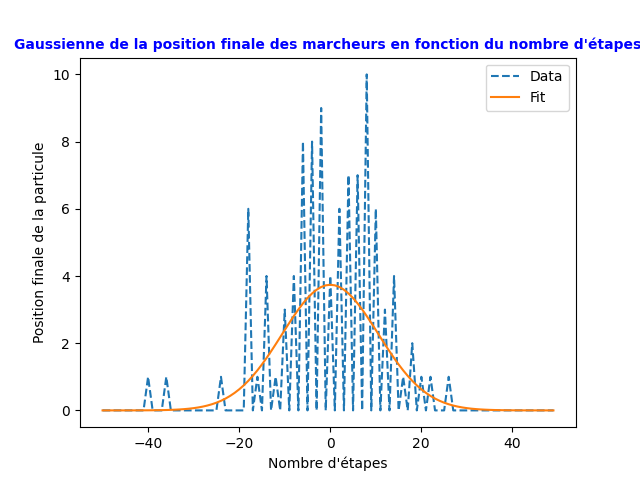

In [3]:
from scipy.optimize import curve_fit
xdata = np.arange(-N/2,(N/2),1)
ydata = fréquence
def Gauss(x, A, B):
    return A * np.exp(-B * x**2)

parameters, _ = curve_fit(Gauss, xdata, ydata)
fit_A, fit_B = parameters
fit_y = Gauss(xdata, fit_A, fit_B)

plt.title("Gaussienne de la position finale des marcheurs en fonction du nombre d'étapes", fontsize=10, color="Blue", fontweight='bold')                      
plt.ylabel("Position finale de la particule")                       
plt.xlabel("Nombre d'étapes")  
plt.plot(xdata, ydata, '--', label='Data')
plt.plot(xdata, fit_y, '-', label='Fit')
plt.legend()
plt.show()
plt.clf()

In [4]:
variance=np.var(Seau)
print('variance :',variance)
écart_type=variance**0.5
print('écart type :',écart_type)
largeur_mi_hauteur=2*(2.355*écart_type)
print('largeur mi-hauteur :',largeur_mi_hauteur)

variance : 129.12759999999997
écart type : 11.363432579990958
largeur mi-hauteur : 53.52176745175741
